# Explainable Recommender System with SHAP
* ### Imports & setup

In [3]:
import pandas as pd
import torch
import pickle
import shap
import numpy as np
import matplotlib.pyplot as plt

from src.neural_cf import ExplainableNeuMF, prepare_split, safe_transform

shap.initjs()

* ### Load data

In [4]:
print("Loading data...")

df = pd.read_parquet("data/processed/master_data_small.parquet")
train_df, test_df = prepare_split(df)

# Sample for SHAP
test_sample = test_df.sample(200, random_state=42)

print("Sample shape:", test_sample.shape)

Loading data...
Sample shape: (200, 28)


* ### Load Encoders & Metadata

In [5]:
print("Loading encoders...")

with open("models/user_encoder.pkl", "rb") as f:
    user_encoder = pickle.load(f)

with open("models/item_encoder.pkl", "rb") as f:
    item_encoder = pickle.load(f)

with open("models/genre_cols.pkl", "rb") as f:
    genre_cols = pickle.load(f)

feature_names = ["user", "item"] + genre_cols

Loading encoders...


* ### Feature Engineering

In [6]:
users = safe_transform(user_encoder, test_sample['userId'])
items = safe_transform(item_encoder, test_sample['movieId'])
genres = test_sample[genre_cols].values

# Final matrix
X = np.column_stack((users, items, genres))

# Convert to DataFrame for better SHAP visualization
X_df = pd.DataFrame(X, columns=feature_names)

print(X_df.head())

   user  item  (no genres listed)  Action  Adventure  Animation  Children  \
0   610  4235                   0       0          0          0         0   
1   212  8107                   0       0          0          0         0   
2    16  6963                   0       1          1          0         0   
3    74  2317                   0       0          0          0         0   
4   183  2696                   0       0          0          0         0   

   Comedy  Crime  Documentary  ...  Film-Noir  Horror  IMAX  Musical  Mystery  \
0       0      0            0  ...          0       0     0        0        0   
1       0      0            0  ...          0       1     0        0        0   
2       0      1            0  ...          0       0     1        0        0   
3       0      0            0  ...          0       0     0        0        0   
4       0      0            0  ...          0       0     0        0        0   

   Romance  Sci-Fi  Thriller  War  Western  
0    

* ### Load Model

In [7]:
print("Loading model...")

num_users = len(user_encoder.classes_)
num_items = len(item_encoder.classes_)
num_genres = len(genre_cols)

model = ExplainableNeuMF(num_users, num_items, num_genres)

model.load_state_dict(
    torch.load("models/neumf_model_small.pth", map_location="cpu")
)

model.eval()

Loading model...


ExplainableNeuMF(
  (user_embed): Embedding(611, 64)
  (item_embed): Embedding(8247, 64)
  (mlp_pipeline): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
  )
  (output): Linear(in_features=116, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

* ### Prediction Wrapper

In [8]:
def model_predict(x):
    if isinstance(x, pd.DataFrame):
        x = x.values

    x = torch.tensor(x, dtype=torch.float32)

    users = x[:, 0].long()
    items = x[:, 1].long()
    genres = x[:, 2:]

    with torch.no_grad():
        preds = model(users, items, genres).numpy()

    return preds


# Quick sanity check
print(model_predict(X[:5]))

[4.2590675 3.12246   3.488086  4.4726696 3.0819106]


* ### SHAP Explainer

In [9]:
print("Running SHAP...")

# Background dataset
explainer = shap.Explainer(model_predict, X_df.iloc[:50],feature_names=feature_names)

# Get predictions and actuals for this subset
preds = model_predict(X_df.iloc[:100]).flatten()
actuals = test_sample['rating'].iloc[:100].values

# Samples to explain
shap_values = explainer(X_df.iloc[:100])

print("SHAP computation complete.")

Running SHAP...


PermutationExplainer explainer: 101it [00:10,  1.52it/s]                        

SHAP computation complete.


* ### Visualization

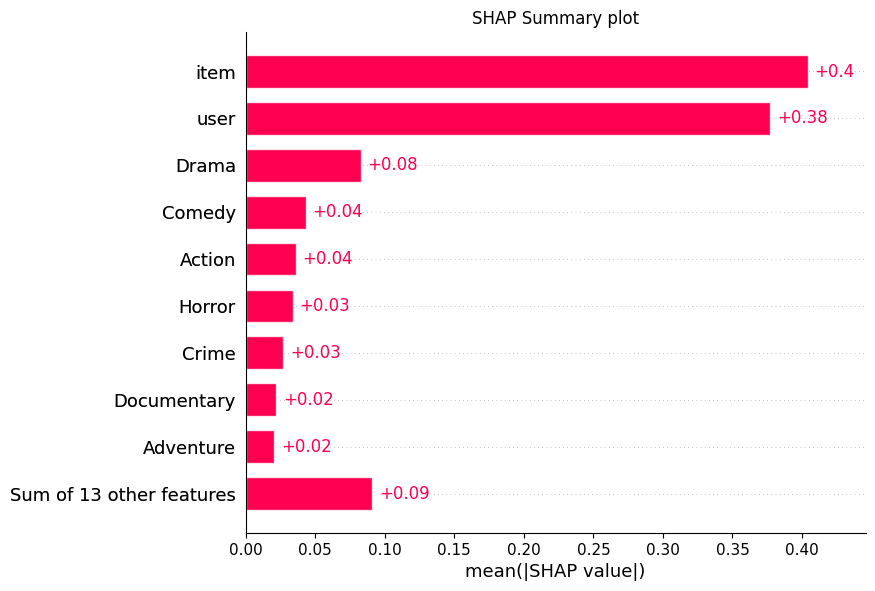

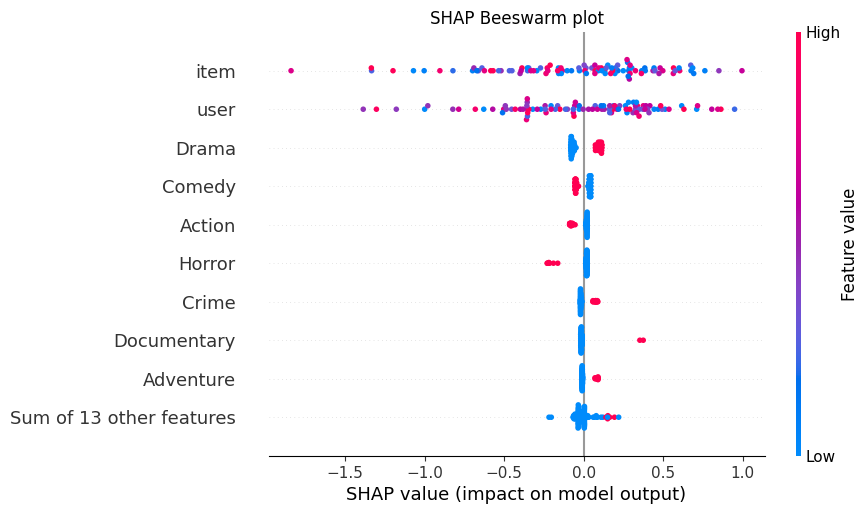

In [10]:
# Summary plot
plt.title("SHAP Summary plot")
shap.plots.bar(shap_values,max_display=10)

# Beeswarm plot
plt.title("SHAP Beeswarm plot")
shap.plots.beeswarm(shap_values)

* The above SHAP plots indicate that the item and user features overwhelmingly dominate the model's predictions, far outweighing the importance of individual movie genres. The beeswarm plot further reveals the directional impact of those minor features; for example, the presence of genres like "Drama" or "Documentary" generally pushes the prediction higher, while "Horror" or "Comedy" tends to lower it.

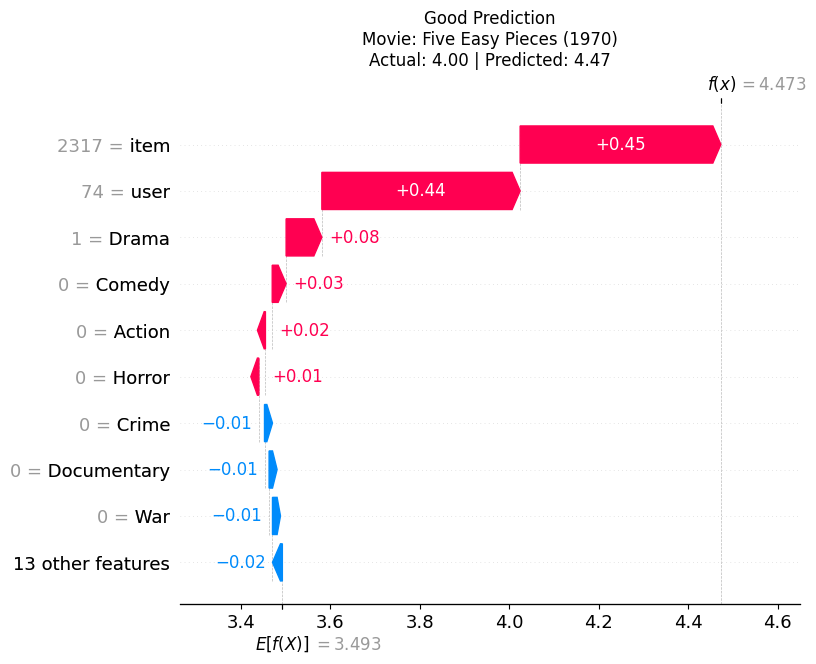

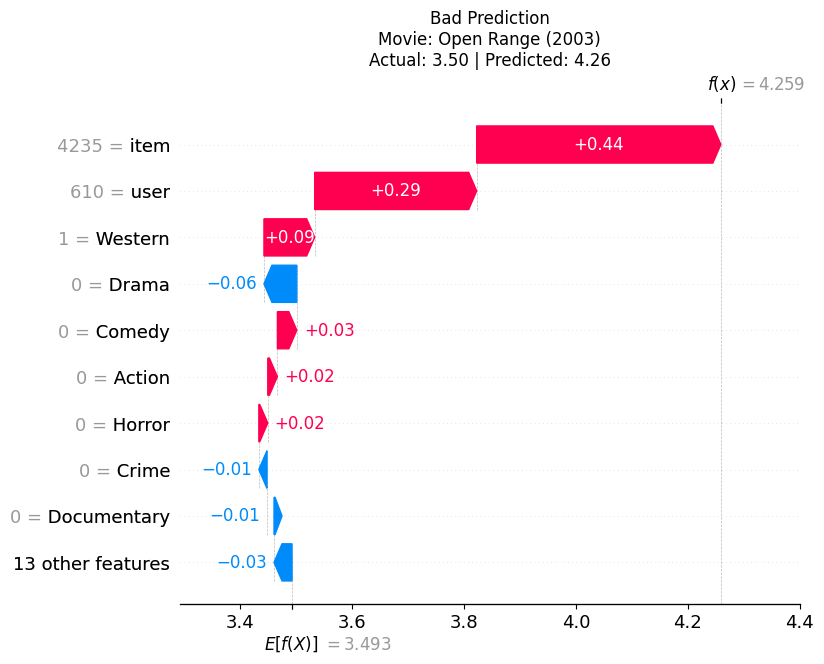

In [11]:
# Calculate errors and find indices based on your 0.5 threshold
errors = np.abs(preds - actuals)

good_idx = np.where(errors <= 0.5)[0][0]
bad_idx = np.where(errors > 0.5)[0][0]

# Waterfall plots of good and bad predictions
# Good Prediction
row = test_sample.iloc[good_idx]

plt.title(
    f"Good Prediction\n"
    f"Movie: {row['title']}\n"
    f"Actual: {row['rating']:.2f} | Predicted: {preds[good_idx]:.2f}"
)

shap.plots.waterfall(shap_values[good_idx])

# Bad Prediction
row = test_sample.iloc[bad_idx]

plt.title(
    f"Bad Prediction\n"
    f"Movie: {row['title']}\n"
    f"Actual: {row['rating']:.2f} | Predicted: {preds[bad_idx]:.2f}"
)

shap.plots.waterfall(shap_values[bad_idx])

* **Good Prediction Plot (Actual: 4.00):**
In this case, the model correctly pushes the baseline score up to a high 4.47, closely tracking the actual positive rating of 4.00. This upward shift is almost entirely driven by the strong positive historical biases associated with user 74 and the _Five Easy Pieces (1970)_ movie , with the movie actually being a "Drama" providing an extra little nudge in the right direction.

* **Bad Prediction Plot (Actual: 3.50):**
Here, the model significantly overshoots the mark by predicting a 4.26 when the actual rating was only a mediocre 3.50. This error occurs because the model's learned weights for user 610 and the _Open Range (2003)_ movie are so overwhelmingly positive that they forcefully drag the prediction too high, overpowering any nuanced genre signals.